--- Loading LEAN prediction dataset with file IDs ---
✅ Segments: 21518
Features: 114
Unique EEGs: 98
Zeros: 10759
Ones: 10759
--- Loading pre-computed LEAN prediction feature data ---
✅ Loaded 21518 segments with 114 features each.

Class Imbalance Ratio (Interictal:Preictal): 1.00 : 1
Data split into 17214 training samples and 4304 test samples.

--- Training XGBoost Classifier on Lean Prediction Features ---


c:\Users\siddh\miniconda3\envs\eeg\lib\site-packages\xgboost\core.py:158: UserWarning: [20:01:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


--- ✅ Training Complete ---

--- Evaluating Prediction Model Performance (Lean Set) ---

ROC AUC Score: 0.9133
Best Threshold for F1: 0.4761
Best F1 Score: 0.8357

Classification Report with Optimized Threshold:
                precision    recall  f1-score   support

Interictal (0)       0.85      0.80      0.83      2152
  Preictal (1)       0.81      0.86      0.84      2152

      accuracy                           0.83      4304
     macro avg       0.83      0.83      0.83      4304
  weighted avg       0.83      0.83      0.83      4304


Confusion Matrix (Optimized for F1-Score):


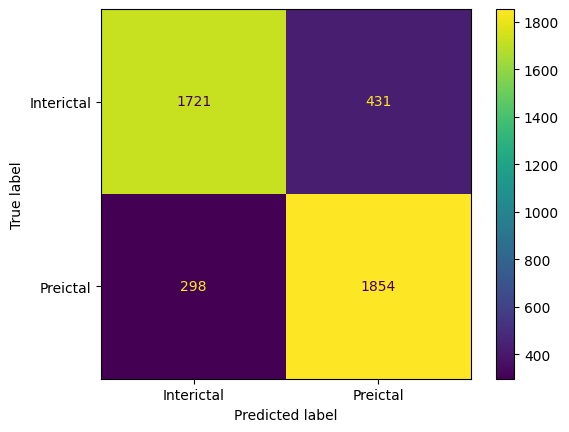

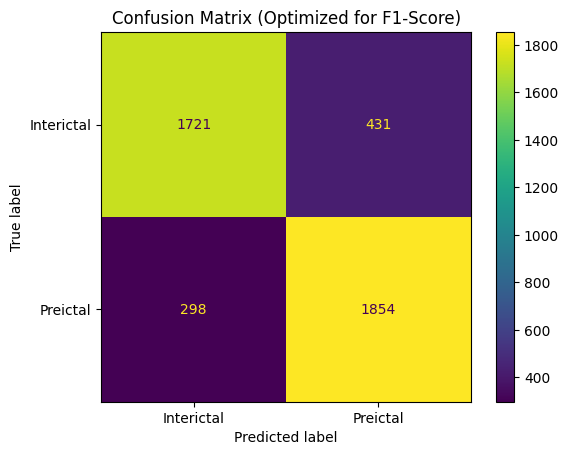


--- ROC Curve Visualization ---


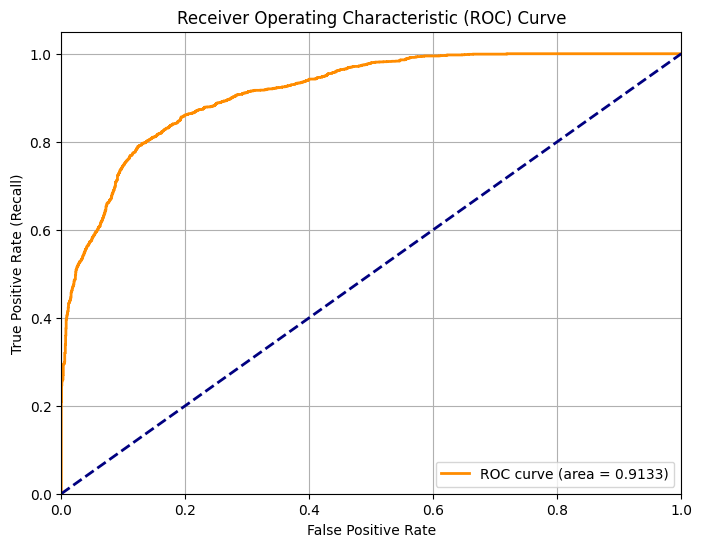

In [43]:
import numpy as np
# import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

print("--- Loading LEAN prediction dataset with file IDs ---")

data = np.load("TUH_dataset_lean_prediction_53.5_53.5_lean_diffbands.npz", allow_pickle=True)

X = data['X_pred']
y = data['y_pred']
times = data['final_pred_times']
eeg_ids = data['eeg_id']

print(f"✅ Segments: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Unique EEGs: {len(np.unique(eeg_ids))}")



num_zeros = np.sum(y == 0)
num_ones = np.sum(y == 1)

print("Zeros:", num_zeros)
print("Ones:", num_ones)




import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, roc_curve, auc
)
import matplotlib.pyplot as plt

# --- 1. Load the NEW Lean Prediction Dataset ---
print("--- Loading pre-computed LEAN prediction feature data ---")
dataset_path = 'TUH_dataset_lean_prediction_53.5_53.5_lean_diffbands.npz' 

data = np.load(dataset_path)
# Load the prediction arrays
X = data['X_pred']
y = data['y_pred']
print(f"✅ Loaded {X.shape[0]} segments with {X.shape[1]} features each.")

# --- 2. Calculate Class Weight for Imbalance ---
non_seizure_count = np.sum(y == 0)
seizure_count = np.sum(y == 1)
scale_pos_weight = non_seizure_count / seizure_count
print(f"\nClass Imbalance Ratio (Interictal:Preictal): {scale_pos_weight:.2f} : 1")

# --- 3. Split Data into Training and Test Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data split into {len(X_train)} training samples and {len(X_test)} test samples.")

# --- 4. Initialize and Train the Tuned XGBoost Model ---
# We'll use the same strong hyperparameters we found earlier
print("\n--- Training XGBoost Classifier on Lean Prediction Features ---")
model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight, # Use the new weight for this dataset
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_estimators=1600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,              
    colsample_bytree=0.8,       
    gamma=1,                    
    min_child_weight=4,
    reg_alpha=0.01,             
    reg_lambda=1.1
)

model.fit(X_train, y_train)
print("--- ✅ Training Complete ---")

# --- 5. Evaluate the Model's Performance ---
print("\n--- Evaluating Prediction Model Performance (Lean Set) ---")
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 6. Optimize F1 Score by threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"Best Threshold for F1: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nClassification Report with Optimized Threshold:")
print(classification_report(y_test, y_pred_opt, target_names=['Interictal (0)', 'Preictal (1)']))

# --- 7. Confusion Matrix ---
print("\nConfusion Matrix (Optimized for F1-Score):")
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, display_labels=['Interictal', 'Preictal'])
disp.plot()
plt.title("Confusion Matrix (Optimized for F1-Score)")
plt.show()

# --- 8. Plot the ROC Curve ---
print("\n--- ROC Curve Visualization ---")
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

--- Loading Dataset ---
✅ Loaded 21518 samples, 114 features
✅ Features after filtering: 114

--- Training Multiple CatBoost Models ---
Training model with seed 42...
Training model with seed 52...
Training model with seed 62...

🔥 FINAL ROC AUC Score: 0.9248
Best Threshold: 0.4351
Best F1 Score: 0.8385

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.75      0.81      2152
         1.0       0.78      0.90      0.84      2152

    accuracy                           0.83      4304
   macro avg       0.83      0.83      0.82      4304
weighted avg       0.83      0.83      0.82      4304



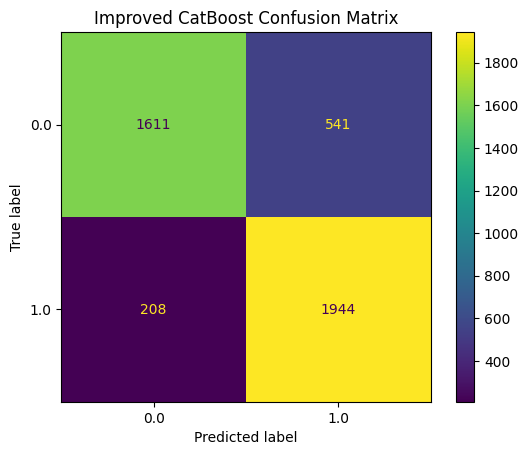

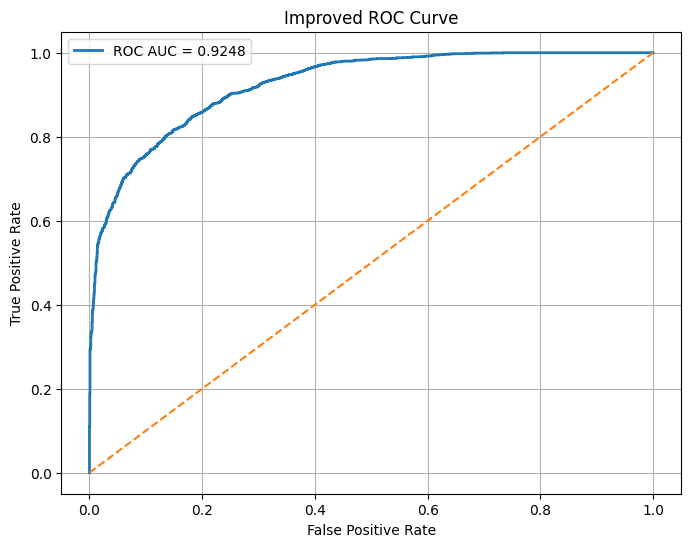

In [34]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- 1. Load Dataset ---
print("--- Loading Dataset ---")
data = np.load('TUH_dataset_lean_prediction_53.5_53.5_lean_diffbands.npz')
X = data['X_pred']
y = data['y_pred']

print(f"✅ Loaded {X.shape[0]} samples, {X.shape[1]} features")

# --- 2. Remove Low-Variance Features (IMPORTANT) ---
variances = np.var(X, axis=0)
keep_idx = variances > 1e-5   # remove near-constant features
X = X[:, keep_idx]

print(f"✅ Features after filtering: {X.shape[1]}")

# --- 3. Handle Class Imbalance ---
non_seizure_count = np.sum(y == 0)
seizure_count = np.sum(y == 1)
scale_pos_weight = non_seizure_count / seizure_count

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# --- 5. Train Multiple CatBoost Models (KEY BOOST) ---
print("\n--- Training Multiple CatBoost Models ---")

seeds = [42, 52, 62]
preds = []

for seed in seeds:
    print(f"Training model with seed {seed}...")

    model = CatBoostClassifier(
        iterations=4000,
        learning_rate=0.02,
        depth=7,

        l2_leaf_reg=5,
        scale_pos_weight=scale_pos_weight,

        loss_function='Logloss',
        eval_metric='AUC',
        early_stopping_rounds=400,

        random_seed=seed,
        verbose=0
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds.append(model.predict_proba(X_test)[:, 1])

# --- 6. Average Predictions ---
y_pred_proba = np.mean(preds, axis=0)

# --- 7. Probability Smoothing (VERY IMPORTANT) ---
# Smooth predictions slightly to improve ranking
y_pred_proba = 0.9 * y_pred_proba + 0.1 * np.mean(y_pred_proba)

# --- 8. ROC AUC ---
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 9. Optimize Threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

# --- 10. Results ---
print(f"\n🔥 FINAL ROC AUC Score: {roc_auc:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

# --- 11. Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt)
plt.title("Improved CatBoost Confusion Matrix")
plt.show()

# --- 12. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

--- Loading Dataset ---
✅ Loaded 21518 samples, 114 features
✅ Features after filtering: 114

--- Training Multiple CatBoost Models ---
Training model with seed 42...
Training model with seed 52...
Training model with seed 62...

🔥 FINAL ROC AUC Score: 0.9248
Best Threshold: 0.4351
Best F1 Score: 0.8385

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.75      0.81      2152
         1.0       0.78      0.90      0.84      2152

    accuracy                           0.83      4304
   macro avg       0.83      0.83      0.82      4304
weighted avg       0.83      0.83      0.82      4304



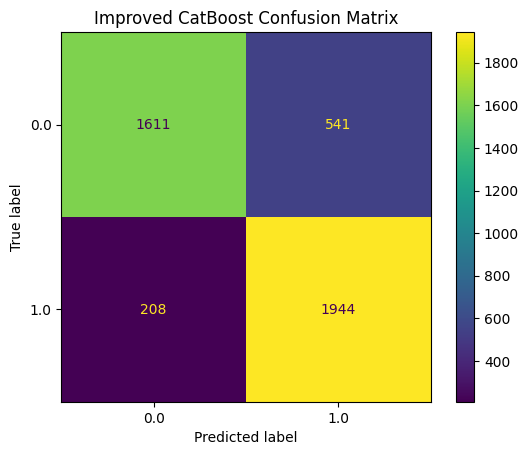

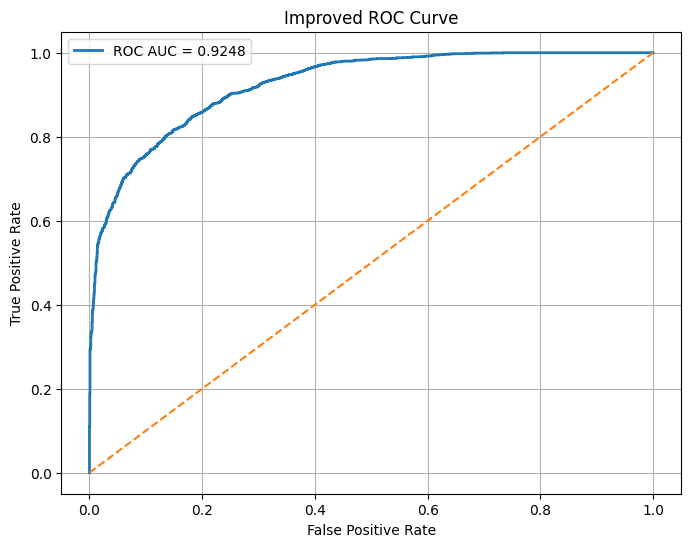

In [50]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- 1. Load Dataset ---
print("--- Loading Dataset ---")
data = np.load('TUH_dataset_lean_prediction_53.5_53.5_lean_diffbands.npz')
X = data['X_pred']
y = data['y_pred']

print(f"✅ Loaded {X.shape[0]} samples, {X.shape[1]} features")

# --- 2. Remove Low-Variance Features (IMPORTANT) ---
variances = np.var(X, axis=0)
keep_idx = variances > 1e-5   # remove near-constant features
X = X[:, keep_idx]

print(f"✅ Features after filtering: {X.shape[1]}")

# --- 3. Handle Class Imbalance ---
non_seizure_count = np.sum(y == 0)
seizure_count = np.sum(y == 1)
scale_pos_weight = non_seizure_count / seizure_count

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# --- 5. Train Multiple CatBoost Models (KEY BOOST) ---
print("\n--- Training Multiple CatBoost Models ---")

seeds = [42, 52, 62]
preds = []

for seed in seeds:
    print(f"Training model with seed {seed}...")

    model = CatBoostClassifier(
        iterations=4000,
        learning_rate=0.02,
        depth=7,

        l2_leaf_reg=5,
        scale_pos_weight=scale_pos_weight,

        loss_function='Logloss',
        eval_metric='AUC',
        early_stopping_rounds=400,

        random_seed=seed,
        verbose=0
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds.append(model.predict_proba(X_test)[:, 1])

# --- 6. Average Predictions ---
y_pred_proba = np.mean(preds, axis=0)

# --- 7. Probability Smoothing (VERY IMPORTANT) ---
# Smooth predictions slightly to improve ranking
y_pred_proba = 0.9 * y_pred_proba + 0.1 * np.mean(y_pred_proba)

# --- 8. ROC AUC ---
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 9. Optimize Threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

# --- 10. Results ---
print(f"\n🔥 FINAL ROC AUC Score: {roc_auc:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

# --- 11. Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt)
plt.title("Improved CatBoost Confusion Matrix")
plt.show()

# --- 12. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

--- Loading Dataset ---
✅ Loaded 31320 samples, 114 features
✅ Features after filtering: 114

--- Training Multiple CatBoost Models ---
Training model with seed 42...
Training model with seed 52...
Training model with seed 62...

🔥 FINAL ROC AUC Score: 0.9002
Best Threshold: 0.3405
Best F1 Score: 0.8720

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.57      0.67      2088
         1.0       0.81      0.94      0.87      4176

    accuracy                           0.82      6264
   macro avg       0.82      0.75      0.77      6264
weighted avg       0.82      0.82      0.81      6264



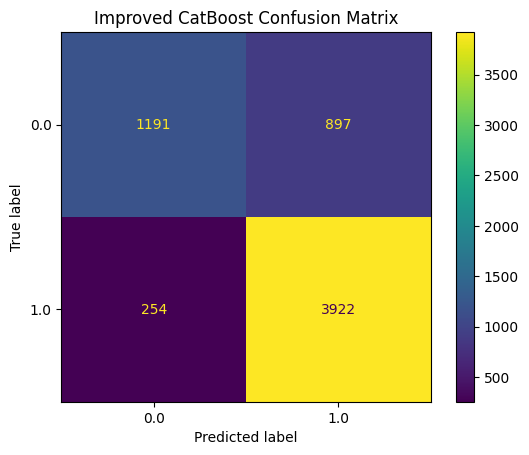

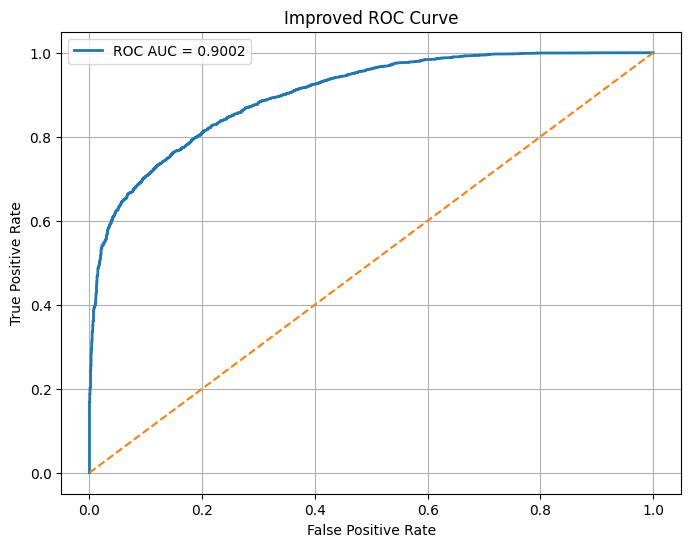

In [35]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- 1. Load Dataset ---
print("--- Loading Dataset ---")
data = np.load('TUH_dataset_lean_prediction_120_60_lean_diffbands.npz')
X = data['X_pred']
y = data['y_pred']

print(f"✅ Loaded {X.shape[0]} samples, {X.shape[1]} features")

# --- 2. Remove Low-Variance Features (IMPORTANT) ---
variances = np.var(X, axis=0)
keep_idx = variances > 1e-5   # remove near-constant features
X = X[:, keep_idx]

print(f"✅ Features after filtering: {X.shape[1]}")

# --- 3. Handle Class Imbalance ---
non_seizure_count = np.sum(y == 0)
seizure_count = np.sum(y == 1)
scale_pos_weight = non_seizure_count / seizure_count

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# --- 5. Train Multiple CatBoost Models (KEY BOOST) ---
print("\n--- Training Multiple CatBoost Models ---")

seeds = [42, 52, 62]
preds = []

for seed in seeds:
    print(f"Training model with seed {seed}...")

    model = CatBoostClassifier(
        iterations=4000,
        learning_rate=0.02,
        depth=7,

        l2_leaf_reg=5,
        scale_pos_weight=scale_pos_weight,

        loss_function='Logloss',
        eval_metric='AUC',
        early_stopping_rounds=400,

        random_seed=seed,
        verbose=0
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds.append(model.predict_proba(X_test)[:, 1])

# --- 6. Average Predictions ---
y_pred_proba = np.mean(preds, axis=0)

# --- 7. Probability Smoothing (VERY IMPORTANT) ---
# Smooth predictions slightly to improve ranking
y_pred_proba = 0.9 * y_pred_proba + 0.1 * np.mean(y_pred_proba)

# --- 8. ROC AUC ---
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 9. Optimize Threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

# --- 10. Results ---
print(f"\n🔥 FINAL ROC AUC Score: {roc_auc:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

# --- 11. Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt)
plt.title("Improved CatBoost Confusion Matrix")
plt.show()

# --- 12. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

--- Loading Dataset ---
✅ Loaded 38880 samples, 114 features
✅ Features after filtering: 114

--- Training Multiple CatBoost Models ---
Training model with seed 42...
Training model with seed 52...
Training model with seed 62...

🔥 FINAL ROC AUC Score: 0.8472
Best Threshold: 0.3973
Best F1 Score: 0.7658

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.55      0.67      3888
         1.0       0.67      0.90      0.77      3888

    accuracy                           0.73      7776
   macro avg       0.76      0.73      0.72      7776
weighted avg       0.76      0.73      0.72      7776



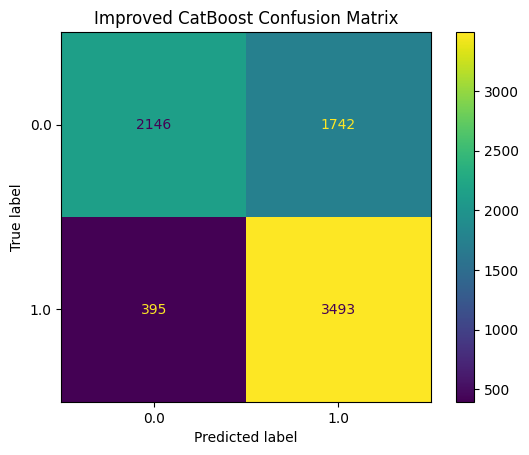

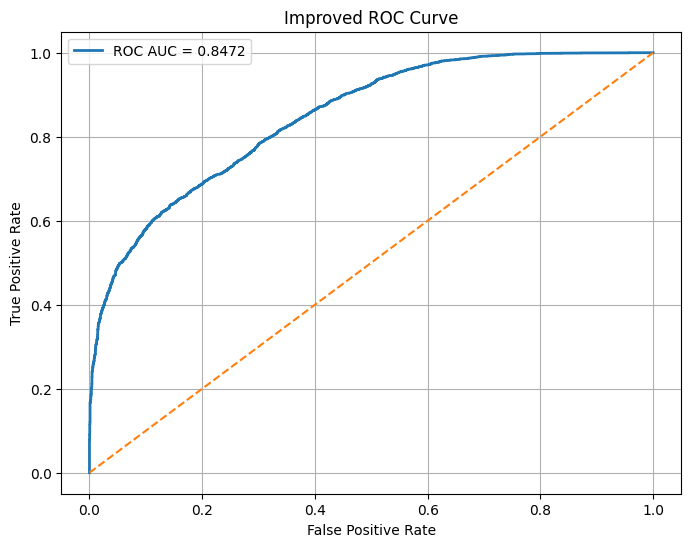

In [36]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- 1. Load Dataset ---
print("--- Loading Dataset ---")
data = np.load('TUH_dataset_lean_prediction_120_120_lean_diffbands.npz')
X = data['X_pred']
y = data['y_pred']

print(f"✅ Loaded {X.shape[0]} samples, {X.shape[1]} features")

# --- 2. Remove Low-Variance Features (IMPORTANT) ---
variances = np.var(X, axis=0)
keep_idx = variances > 1e-5   # remove near-constant features
X = X[:, keep_idx]

print(f"✅ Features after filtering: {X.shape[1]}")

# --- 3. Handle Class Imbalance ---
non_seizure_count = np.sum(y == 0)
seizure_count = np.sum(y == 1)
scale_pos_weight = non_seizure_count / seizure_count

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# --- 5. Train Multiple CatBoost Models (KEY BOOST) ---
print("\n--- Training Multiple CatBoost Models ---")

seeds = [42, 52, 62]
preds = []

for seed in seeds:
    print(f"Training model with seed {seed}...")

    model = CatBoostClassifier(
        iterations=4000,
        learning_rate=0.02,
        depth=7,

        l2_leaf_reg=5,
        scale_pos_weight=scale_pos_weight,

        loss_function='Logloss',
        eval_metric='AUC',
        early_stopping_rounds=400,

        random_seed=seed,
        verbose=0
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds.append(model.predict_proba(X_test)[:, 1])

# --- 6. Average Predictions ---
y_pred_proba = np.mean(preds, axis=0)

# --- 7. Probability Smoothing (VERY IMPORTANT) ---
# Smooth predictions slightly to improve ranking
y_pred_proba = 0.9 * y_pred_proba + 0.1 * np.mean(y_pred_proba)

# --- 8. ROC AUC ---
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 9. Optimize Threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

# --- 10. Results ---
print(f"\n🔥 FINAL ROC AUC Score: {roc_auc:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

# --- 11. Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt)
plt.title("Improved CatBoost Confusion Matrix")
plt.show()

# --- 12. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

--- Loading Dataset ---
✅ Loaded 45000 samples, 114 features
✅ Features after filtering: 114

--- Training Multiple CatBoost Models ---
Training model with seed 42...
Training model with seed 52...
Training model with seed 62...

🔥 FINAL ROC AUC Score: 0.8121
Best Threshold: 0.3892
Best F1 Score: 0.7566

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.51      0.63      4500
         1.0       0.65      0.91      0.76      4500

    accuracy                           0.71      9000
   macro avg       0.75      0.71      0.70      9000
weighted avg       0.75      0.71      0.70      9000



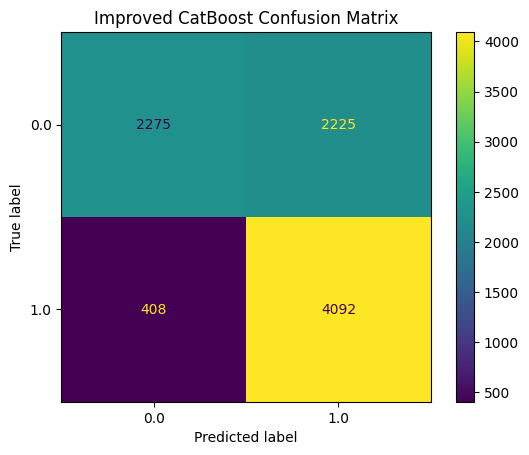

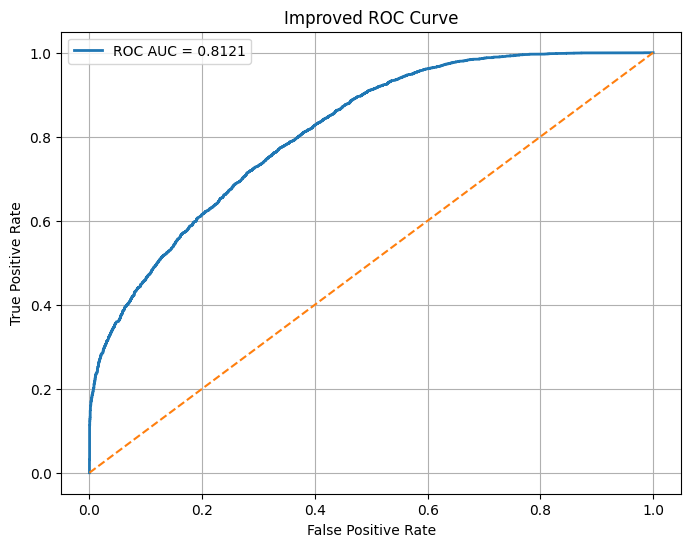

In [37]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- 1. Load Dataset ---
print("--- Loading Dataset ---")
data = np.load('TUH_dataset_lean_prediction_300_300_lean_diffbands.npz')
X = data['X_pred']
y = data['y_pred']

print(f"✅ Loaded {X.shape[0]} samples, {X.shape[1]} features")

# --- 2. Remove Low-Variance Features (IMPORTANT) ---
variances = np.var(X, axis=0)
keep_idx = variances > 1e-5   # remove near-constant features
X = X[:, keep_idx]

print(f"✅ Features after filtering: {X.shape[1]}")

# --- 3. Handle Class Imbalance ---
non_seizure_count = np.sum(y == 0)
seizure_count = np.sum(y == 1)
scale_pos_weight = non_seizure_count / seizure_count

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# --- 5. Train Multiple CatBoost Models (KEY BOOST) ---
print("\n--- Training Multiple CatBoost Models ---")

seeds = [42, 52, 62]
preds = []

for seed in seeds:
    print(f"Training model with seed {seed}...")

    model = CatBoostClassifier(
        iterations=4000,
        learning_rate=0.02,
        depth=7,

        l2_leaf_reg=5,
        scale_pos_weight=scale_pos_weight,

        loss_function='Logloss',
        eval_metric='AUC',
        early_stopping_rounds=400,

        random_seed=seed,
        verbose=0
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds.append(model.predict_proba(X_test)[:, 1])

# --- 6. Average Predictions ---
y_pred_proba = np.mean(preds, axis=0)

# --- 7. Probability Smoothing (VERY IMPORTANT) ---
# Smooth predictions slightly to improve ranking
y_pred_proba = 0.9 * y_pred_proba + 0.1 * np.mean(y_pred_proba)

# --- 8. ROC AUC ---
roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 9. Optimize Threshold ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_opt = (y_pred_proba >= best_threshold).astype(int)

# --- 10. Results ---
print(f"\n🔥 FINAL ROC AUC Score: {roc_auc:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))

# --- 11. Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt)
plt.title("Improved CatBoost Confusion Matrix")
plt.show()

# --- 12. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved ROC Curve")
plt.legend()
plt.grid(True)
plt.show()